# lenseff tutorial: a detection-efficiency map from end to end

This notebook builds a small efficiency map for a Roman-like survey, one step at
a time, and finishes with the contour plot. It runs in a couple of minutes.

The single methodological point to keep in view: the detection statistic is the
chi-square difference between the binary-lens model and a **freely refitted**
PSPL model. A free single-lens fit reabsorbs part of a planetary anomaly, and
this notebook measures how much.

## 1. The configuration

Everything is set from YAML. We start from the shipped demo config and shrink the grid so the notebook runs quickly.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from lenseff.config import Config

ROOT = Path.cwd().parent if Path.cwd().name == "docs" else Path.cwd()
document = yaml.safe_load((ROOT / "configs" / "roman_gbtds_demo.yaml").read_text())

document["run"]["name"] = "tutorial"
document["run"]["output_dir"] = "results/tutorial"
document["events"]["n_events"] = 3
document["injection"]["grid"]["log_q"] = {"min": -5.0, "max": -2.0, "n": 5}
document["injection"]["grid"]["log_s"] = {"min": -0.4, "max": 0.4, "n": 5}
document["injection"]["grid"]["n_alpha"] = 6
document["injection"]["n_zero_q_trials"] = 20

config = Config.from_dict(document)
print("config hash:", config.config_hash())
print("injections :", f"{config.n_injections():,}")

config hash: 0e0318cf7465123fe2bbfd1ea502b01da32a3e7ec4f6e33fe4faf82024e2ab9e
injections : 470


The hash covers everything that can change a number — survey, events, grid,
criteria — but *not* the `compute` section, so the same run can be resumed on a
machine with a different core count without invalidating it.

## 2. The survey

A `Survey` is the realised observing calendar plus the photometric error model.

In [2]:
from lenseff.survey import Survey

survey = Survey.from_config(config.survey, config.run.seed)
for key, value in survey.summary().items():
    print(f"{key:>20}: {value}")

              preset: roman_gbtds
                band: W149
     cadence_minutes: 12.0
           n_seasons: 6
  season_length_days: 72.0
            n_points: 51846
           span_days: 1897.25
          duty_cycle: 0.22769798392410068
     sigma_mag_at_20: 0.00492771275311355
     sigma_mag_at_23: 0.022741286766374037


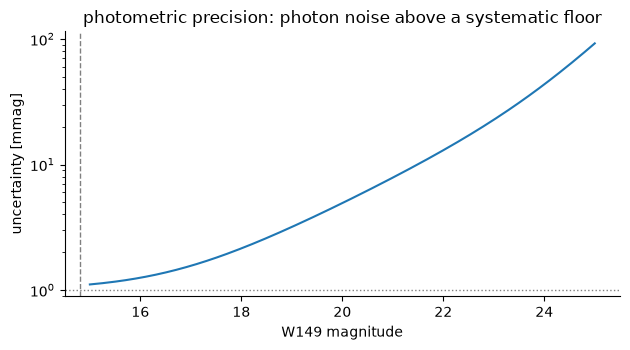

In [3]:
mags = np.linspace(15.0, 25.0, 200)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.semilogy(mags, survey.magnitude_uncertainty(mags) * 1000.0, color="tab:blue")
ax.axhline(survey.photometry.systematic_floor_mmag, ls=":", color="0.5", lw=1.0)
ax.axvline(survey.photometry.saturation_mag, ls="--", color="0.5", lw=1.0)
ax.set_xlabel(f"{survey.photometry.band} magnitude")
ax.set_ylabel("uncertainty [mmag]")
ax.set_title("photometric precision: photon noise above a systematic floor")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()

## 3. A baseline event

Events are drawn from the priors in `events.distributions`, subject to cuts: the peak must fall in a season and the event must be adequately covered.

#0  t_0=2463349.77  u_0=0.056  t_E= 36.7 d  W149=22.77  f_b/f_s=0.26
#1  t_0=2461706.26  u_0=0.780  t_E= 16.5 d  W149=22.74  f_b/f_s=0.31
#2  t_0=2462968.38  u_0=0.601  t_E= 19.7 d  W149=21.75  f_b/f_s=0.36


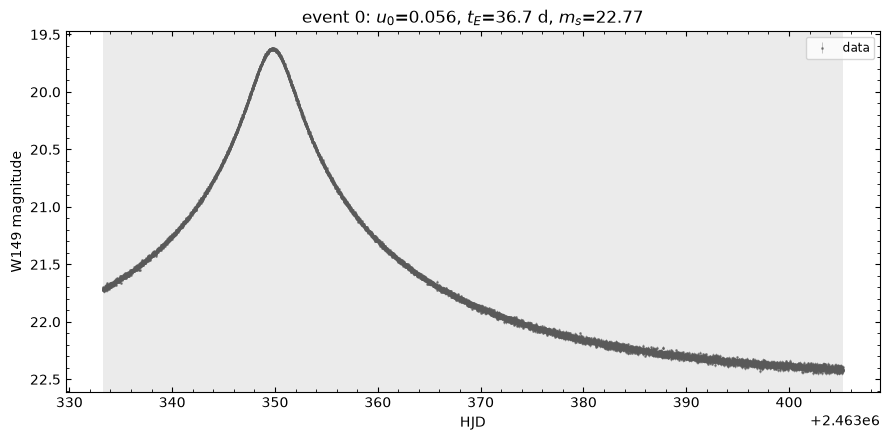

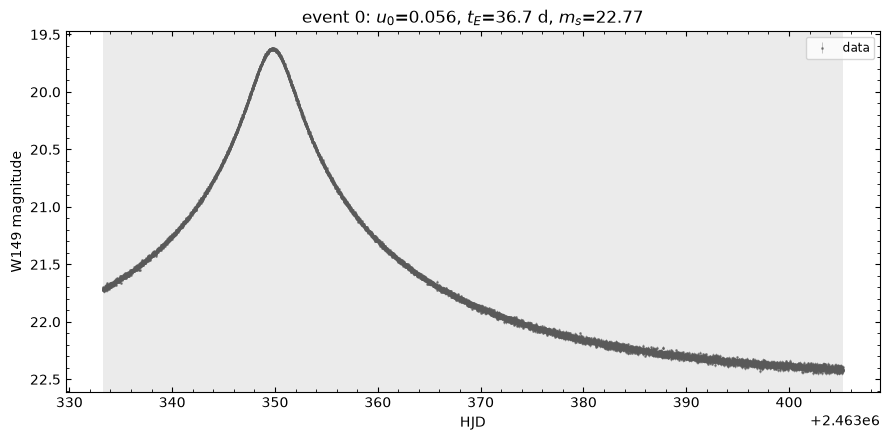

In [4]:
from lenseff.events import sample_events, simulate_light_curve
from lenseff.plotting import plot_light_curve

events = sample_events(config, survey)
for event in events:
    print(
        f"#{event.index}  t_0={event.t_0:.2f}  u_0={event.u_0:.3f}  "
        f"t_E={event.t_E:5.1f} d  W149={event.source_mag:.2f}  f_b/f_s={event.blend_ratio:.2f}"
    )

event = events[0]
light_curve = simulate_light_curve(event, survey, config)
plot_light_curve(light_curve, survey, window_t_E=3.0)

## 4. Injecting a planet

`inject_planet` replaces the PSPL magnification with the binary-lens one.
Finite-source magnification is used only where the source approaches a caustic;
everywhere else the point-source binary solution is exact and about sixty times
cheaper.

points in the analysis window : 8,641
finite-source evaluations     : 0
anomaly duration              : 283.00 h
peak deviation                : 92.6 sigma


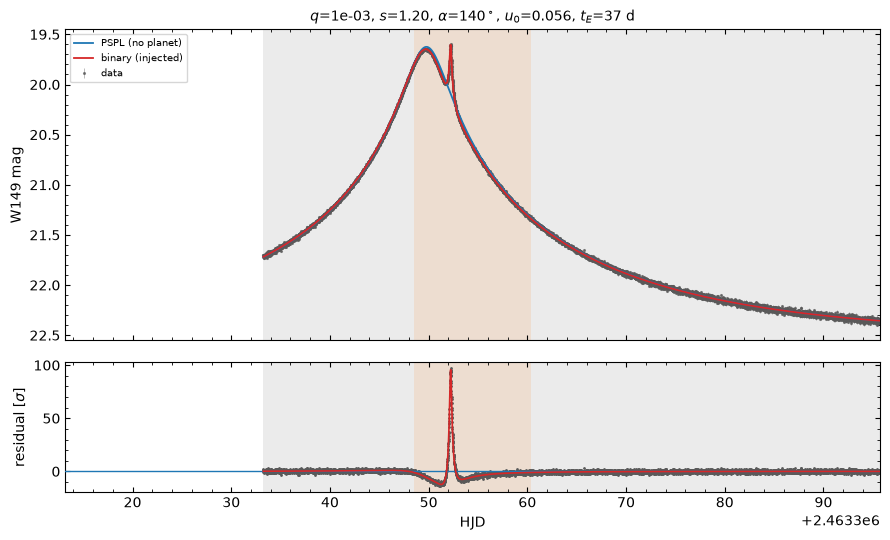

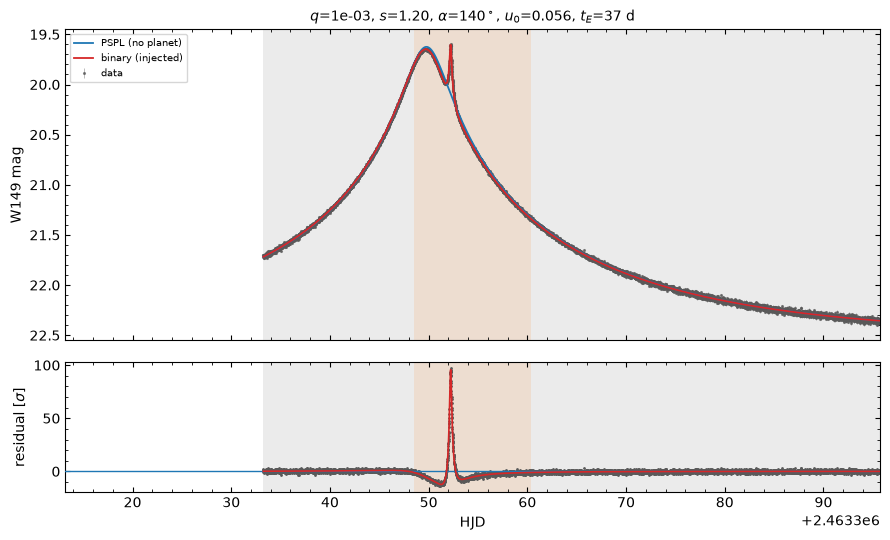

In [5]:
from lenseff.inject import EventSetup, Planet, inject_planet
from lenseff.plotting import plot_injection

setup = EventSetup.build(event, survey, config)
injection = inject_planet(setup, Planet(q=1e-3, s=1.2, alpha_deg=140.0), survey, config)

print(f"points in the analysis window : {injection.light_curve.n_points:,}")
print(f"finite-source evaluations     : {injection.n_finite_source_points}")
print(f"anomaly duration              : {injection.anomaly.duration_days * 24:.2f} h")
print(f"peak deviation                : {injection.anomaly.peak_deviation:.1f} sigma")
plot_injection(injection, survey)

## 5. The detection statistic

Now the part that matters. We compute the statistic two ways: against a free
PSPL refit (correct) and against the *injected* PSPL parameters (the common
error), and compare.

In [6]:
from lenseff.detect import detect, refit_pspl, solve_fluxes

result = detect(injection, survey, config)
fit = refit_pspl(injection, config)

lc = injection.light_curve
naive = solve_fluxes(injection.pspl_magnification, lc.flux, lc.flux_err).chi2
naive_delta = naive - result.chi2_binary

print(f"truth    t_0={event.t_0:.4f}  u_0={event.u_0:.4f}  t_E={event.t_E:.3f}")
print(f"refit    t_0={fit.t_0:.4f}  u_0={fit.u_0:.4f}  t_E={fit.t_E:.3f}")
print()
print(f"delta chi2 vs free refit      : {result.delta_chi2:12,.1f}   <- the statistic")
print(f"delta chi2 vs injected PSPL   : {naive_delta:12,.1f}   <- the common error")
print(f"inflation factor              : {naive_delta / result.delta_chi2:12.2f}x")
print()
for name, passed in result.criteria.items():
    print(f"  {name:<20} {'pass' if passed else 'FAIL'}")
print(f"  {'detected':<20} {result.detected}")

truth    t_0=2463349.7747  u_0=0.0561  t_E=36.734
refit    t_0=2463349.7678  u_0=0.0660  t_E=32.434

delta chi2 vs free refit      :    275,203.9   <- the statistic
delta chi2 vs injected PSPL   :    281,332.8   <- the common error
inflation factor              :         1.02x

  fittable             pass
  delta_chi2           pass
  consecutive_points   pass
  points_in_anomaly    pass
  in_season            pass
  detected             True


The refit moves `t_0`, `u_0` and `t_E` away from the truth to swallow as much
of the anomaly as a single-lens model can. Whatever it cannot swallow is the
detection statistic. The inflation factor is small for a strong anomaly and
large for a marginal one — which is exactly where the efficiency contour sits.

## 6. The sweep

`run_grid` marginalises over trajectory angle and over the event population, in parallel, with checkpointing.

In [7]:
from lenseff.grid import run_grid

output_dir = run_grid(config, progress=True)
print(f"\noutput: {output_dir}")

lenseff tutorial [0e0318cf7465]: 95 of 95 tasks, 470 injections


          6/470       injections    1.3%      2.0/s  elapsed    0.0 min  eta    3.9 min

         12/470       injections    2.6%      4.0/s  elapsed    0.1 min  eta    1.9 min

         18/470       injections    3.8%      6.0/s  elapsed    0.1 min  eta    1.3 min

         24/470       injections    5.1%      8.0/s  elapsed    0.1 min  eta    0.9 min

...

        469/470       injections   99.8%     25.2/s  elapsed    0.3 min  eta    0.0 min

        470/470       injections  100.0%     25.3/s  elapsed    0.3 min  eta    0.0 min

        470/470       injections  100.0%     25.2/s  elapsed    0.3 min  eta    0.0 min


output: results/tutorial



  wrote results/tutorial/injections


## 7. The efficiency surface

Per-cell detected fractions with Wilson score intervals — binomial, not Gaussian, so they stay inside [0, 1] at the edges of the surface where most of the interesting structure is.

In [8]:
from lenseff.efficiency import aggregate, control_summary, load_injections

records = load_injections(output_dir)
surface = aggregate(records, config)
surface[
    ["log_q", "log_s", "n_trials", "n_detected", "efficiency", "efficiency_low", "efficiency_high"]
].head(10)

,log_q,log_s,n_trials,n_detected,efficiency,efficiency_low,efficiency_high
0,-5.00,-0.4,18,0,0.000000,0.000000,0.052634
1,-5.00,-0.2,18,0,0.000000,0.000000,0.052634
2,-5.00,0.0,18,3,0.166667,0.096930,0.271493
3,-5.00,0.2,18,0,0.000000,0.000000,0.052634
4,-5.00,0.4,18,0,0.000000,0.000000,0.052634
5,-4.25,-0.4,18,0,0.000000,0.000000,0.052634
6,-4.25,-0.2,18,1,0.055556,0.021426,0.136471
7,-4.25,0.0,18,5,0.277778,0.186052,0.392896
8,-4.25,0.2,18,1,0.055556,0.021426,0.136471
9,-4.25,0.4,18,0,0.000000,0.000000,0.052634


In [9]:
controls = control_summary(records, config)
for key, value in controls.items():
    print(f"{key:>26}: {value}")

                n_controls: 20
         n_false_positives: 0
       false_positive_rate: 0.0
        false_positive_low: 0.0
       false_positive_high: 0.047621017098760154
            max_delta_chi2: 0.0
   max_delta_chi2_relative: 0.0
 frac_run_criterion_passed: 0.0


The controls are the sanity check. `max_delta_chi2` must not be positive: at
`q = 0` the binary model *is* the injected PSPL model, and a free refit can only
fit at least as well as the truth, so the chi-square criterion cannot fire. Any
positive value beyond float64 rounding would mean the refit is failing to find
its own global minimum.

## 8. The map

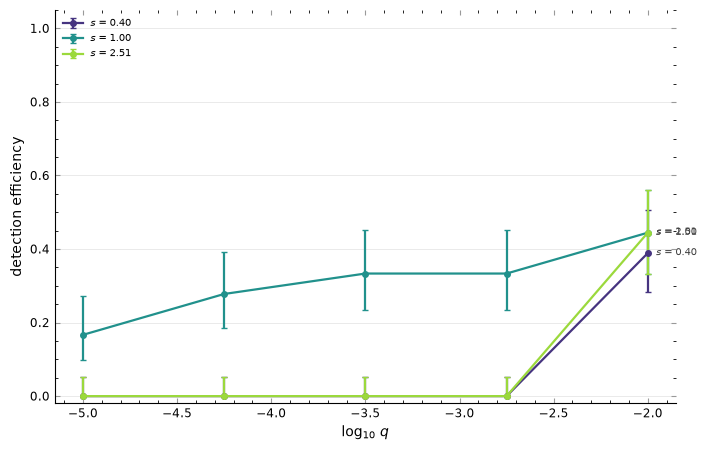

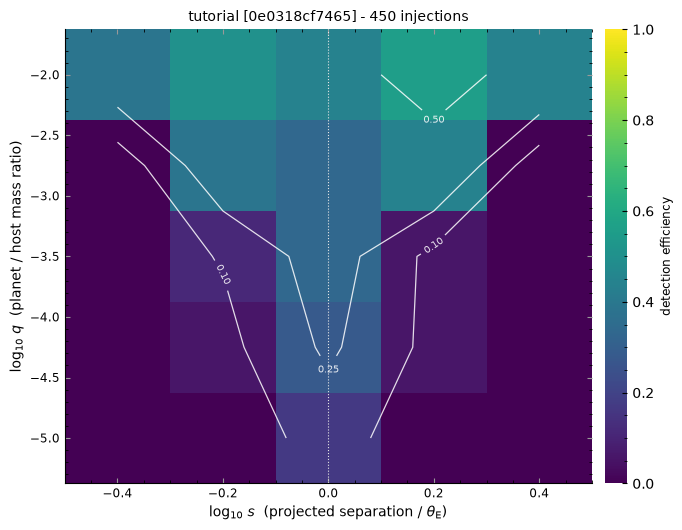

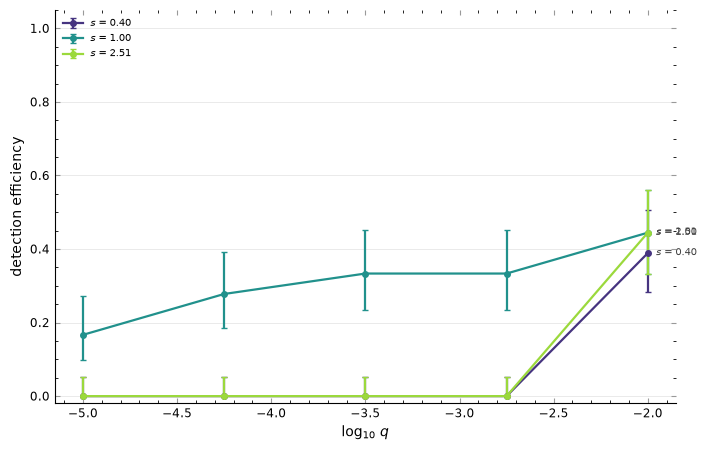

In [10]:
from lenseff.plotting import plot_efficiency_map, plot_efficiency_slices

plot_efficiency_map(surface, config)
plot_efficiency_slices(surface, config, n_slices=3)

Efficiency peaks near `s = 1` — the lensing zone, where the caustics are
largest and closest to the source trajectory — and falls off toward close and
wide separations. It rises monotonically with `q`. Both are asserted as
validation tests, not just observed here.

## Reproducing this

Everything above is a pure function of the configuration and the seed:

```bash
lenseff run configs/roman_gbtds_demo.yaml
```

The parquet output embeds the resolved configuration, its hash, the seed, the
git commit and every dependency version, so a run can be traced back to exactly
what produced it.